# An introduction to seaborn

📄 Source: https://seaborn.pydata.org/tutorial/introduction.html

Seaborn is a library for statistical graphics in Python. It is built **on top of matplotlib** and works closely with **pandas** DataFrames.
You give it a whole dataset and say which column plays which role; seaborn does the semantic mapping (colours, markers, sizes) and the statistical aggregation for you.

> The example datasets are downloaded by `sns.load_dataset(...)` the first time (needs internet), then cached on your computer.

In [1]:
# Import seaborn
import seaborn as sns
import matplotlib as mpl
import pandas as pd

print("seaborn", sns.__version__, "| matplotlib", mpl.__version__, "| pandas", pd.__version__)

seaborn 0.13.2 | matplotlib 3.11.2 | pandas 3.0.2


In [2]:
# Apply the default theme
sns.set_theme()

`set_theme()` changes matplotlib's rcParams, so it affects **all** plots, even pure-matplotlib ones. You can skip it if you prefer matplotlib's defaults (more on themes in notebook 11).

In [3]:
# Load an example dataset (it's just a pandas DataFrame)
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


`load_dataset` is only a shortcut: these are normal DataFrames that you could also load with `pd.read_csv`.

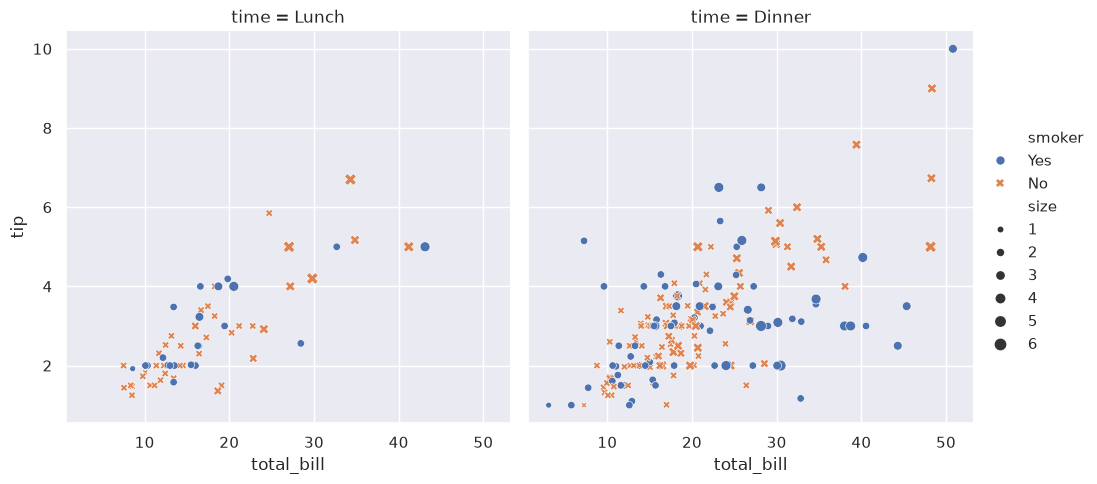

In [4]:
# Create a visualization: 5 variables in one call
sns.relplot(
    data=tips,
    x="total_bill", y="tip",    # position
    col="time",                 # one subplot per value of 'time'
    hue="smoker",               # colour by 'smoker'
    style="smoker",             # marker shape by 'smoker'
    size="size",                # marker size by party size
)

We only gave the **names** of the variables and their **roles**. No colours or marker codes: seaborn translated the data values into matplotlib arguments. This *declarative* approach keeps you focused on the question, not on matplotlib details.

## A high-level API for statistical graphics

Different questions need different plots, and seaborn makes switching easy through a consistent API. `relplot` visualises statistical **rel**ationships. When one variable is time, a line is better than dots: just change `kind`.

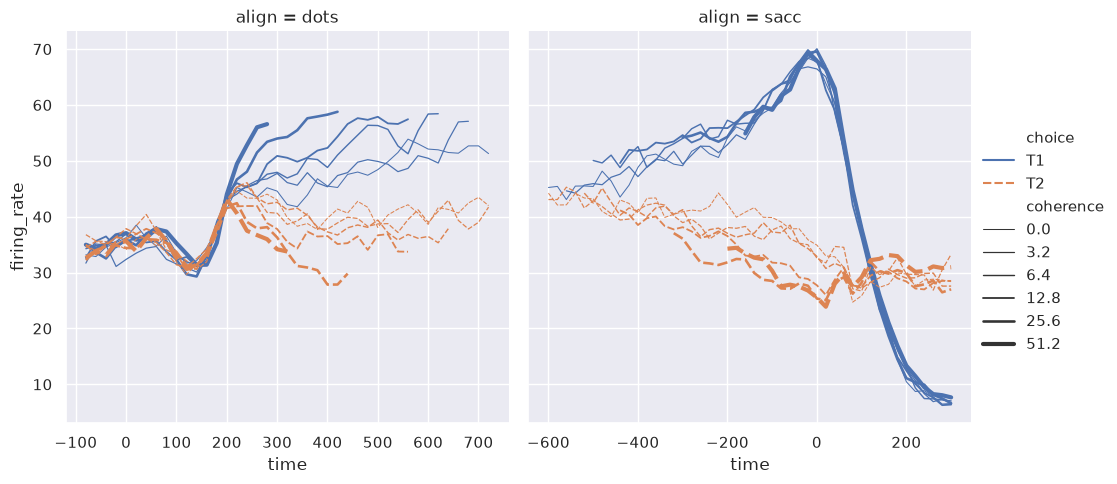

In [5]:
dots = sns.load_dataset("dots")
sns.relplot(
    data=dots, kind="line",               # same function, line instead of scatter
    x="time", y="firing_rate", col="align",
    hue="choice", size="coherence", style="choice",
    facet_kws=dict(sharex=False),         # let each column have its own x range
)

`size` and `style` work in both kinds, but mean different things: marker area/shape in a scatter plot, line width/dashing in a line plot.

### Statistical estimation

Often we want the **average** of one variable as a function of others. Seaborn computes it for you:

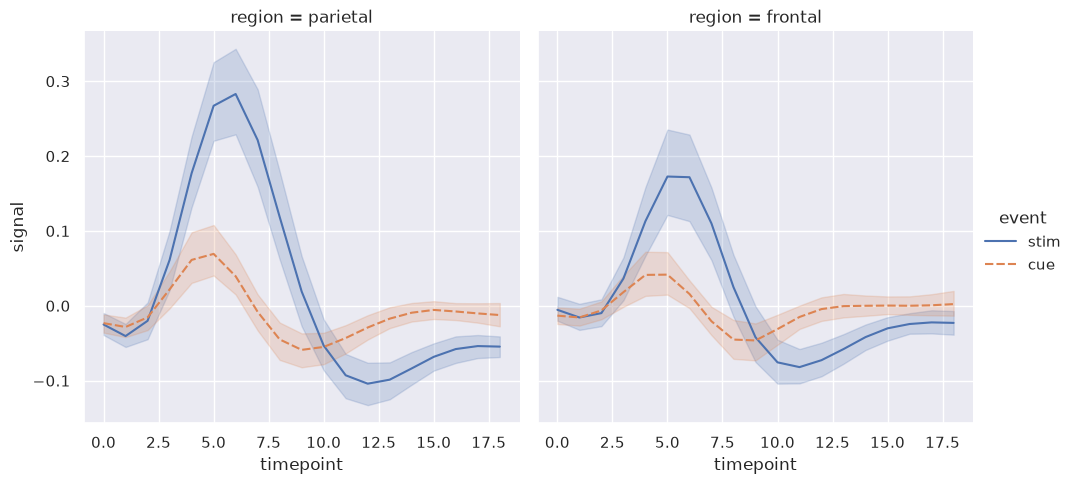

In [6]:
fmri = sns.load_dataset("fmri")
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", col="region",
    hue="event", style="event",
)

Each line is the **mean** at each timepoint; the shaded band is a **bootstrapped confidence interval** showing the uncertainty of that estimate.

It goes beyond descriptive statistics, e.g. `lmplot` adds a linear regression model (and its uncertainty) to a scatterplot:

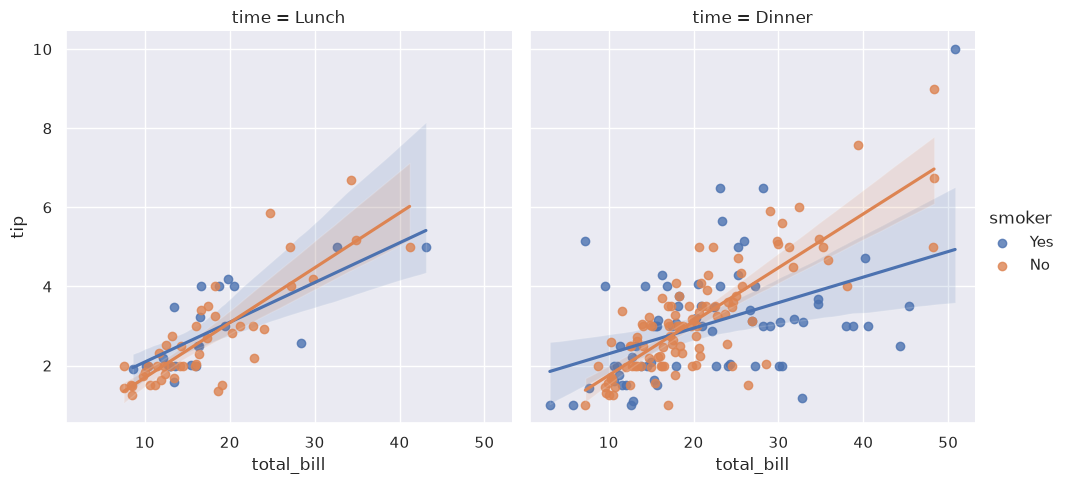

In [7]:
sns.lmplot(data=tips, x="total_bill", y="tip", col="time", hue="smoker")

### Distributional representations

`displot` shows distributions: classic histograms, and kernel density estimates (KDE):

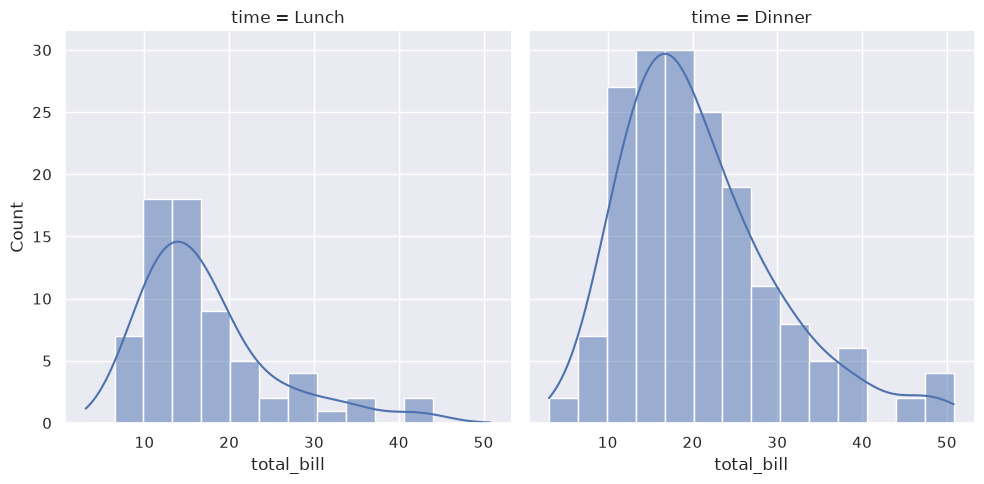

In [8]:
sns.displot(data=tips, x="total_bill", col="time", kde=True)   # histogram + smooth KDE curve

...and less familiar but powerful ones, like the **empirical cumulative distribution function** (ECDF):

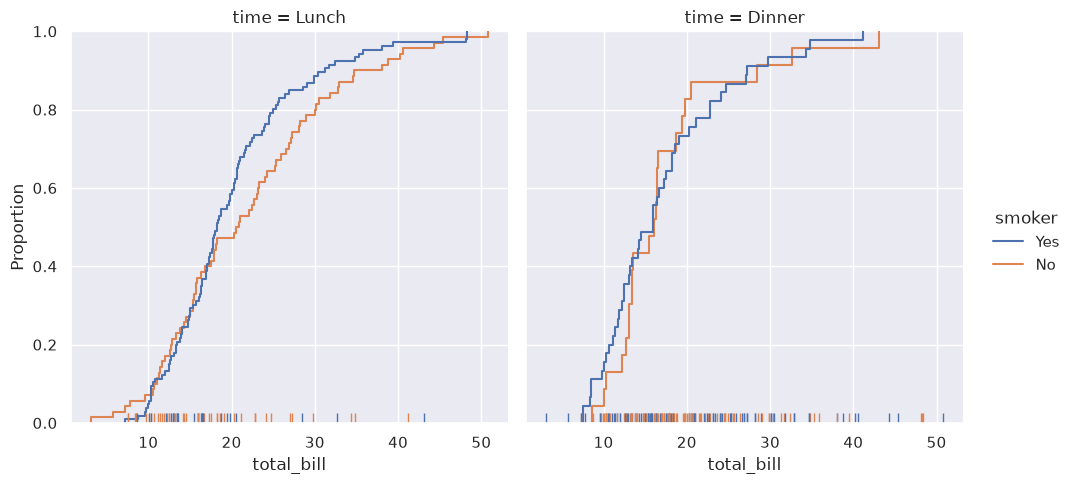

In [9]:
sns.displot(data=tips, kind="ecdf", x="total_bill", col="time", hue="smoker", rug=True)   # rug = a tick for every observation

### Plots for categorical data

`catplot` gives plots for categorical data at different levels of detail. Finest level: a **swarm** plot, every observation, shifted so points don't overlap:

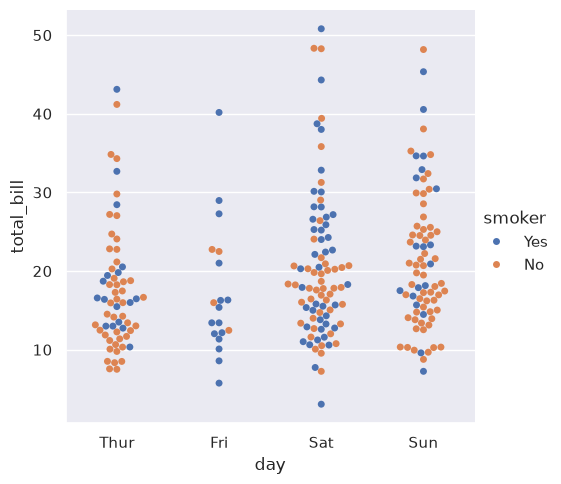

In [10]:
sns.catplot(data=tips, kind="swarm", x="day", y="total_bill", hue="smoker")

Or a KDE of the distribution (violin), here split by `hue`:

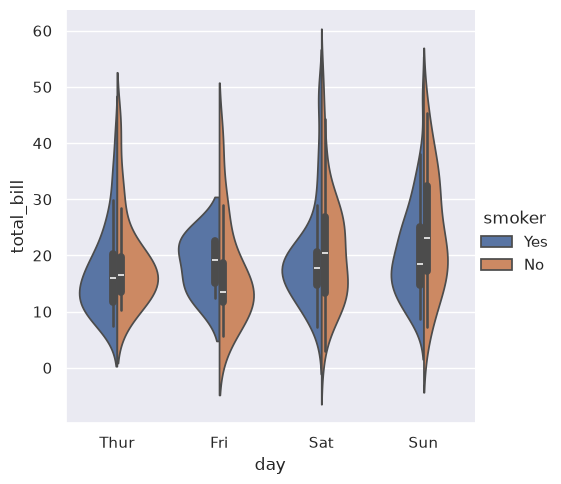

In [11]:
sns.catplot(data=tips, kind="violin", x="day", y="total_bill", hue="smoker", split=True)

Or only the **mean** and its confidence interval for each nested category:

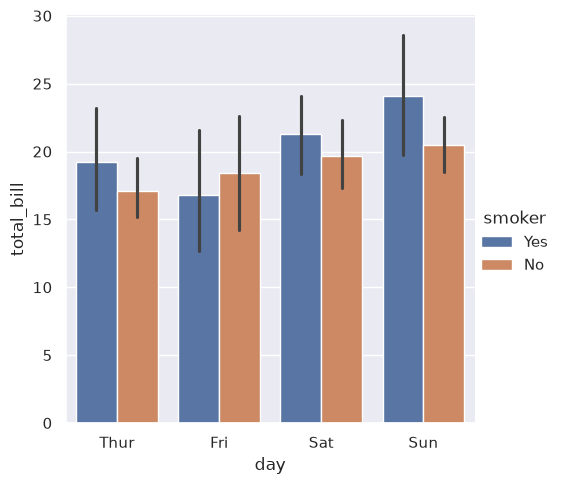

In [12]:
sns.catplot(data=tips, kind="bar", x="day", y="total_bill", hue="smoker")

## Multivariate views on complex datasets

`jointplot` focuses on **one** relationship: the joint distribution of two variables plus each variable's marginal distribution.

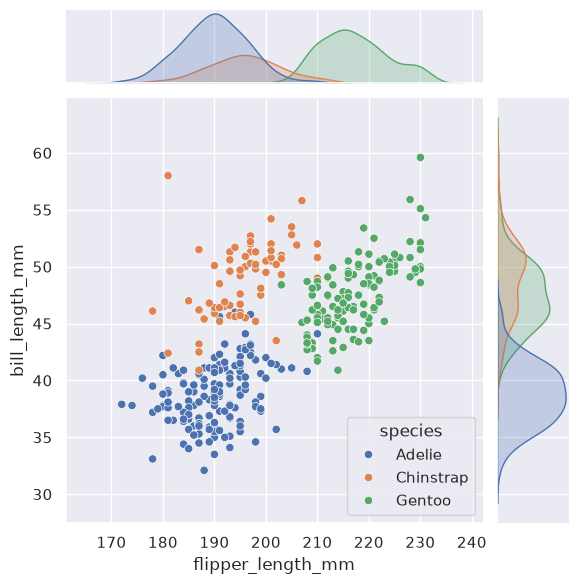

In [13]:
penguins = sns.load_dataset("penguins")
sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species")

`pairplot` takes the broad view: joint distributions for **every pair** of variables, and the marginal distribution of each one on the diagonal.

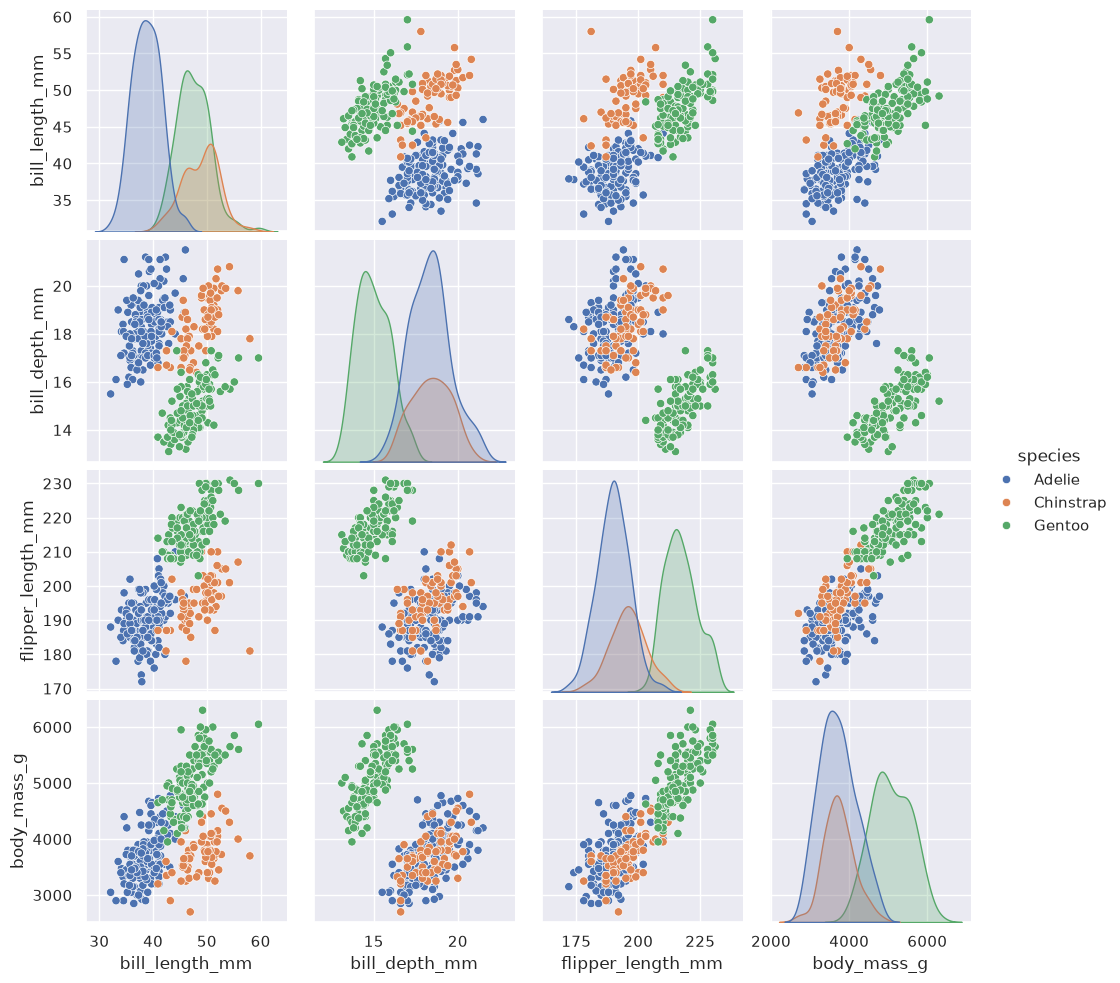

In [14]:
sns.pairplot(data=penguins, hue="species")

### Lower-level tools for building figures

Those functions combine *axes-level* plotting functions with objects that manage the figure layout (grids). Both are public, so you can build custom figures in a few lines:

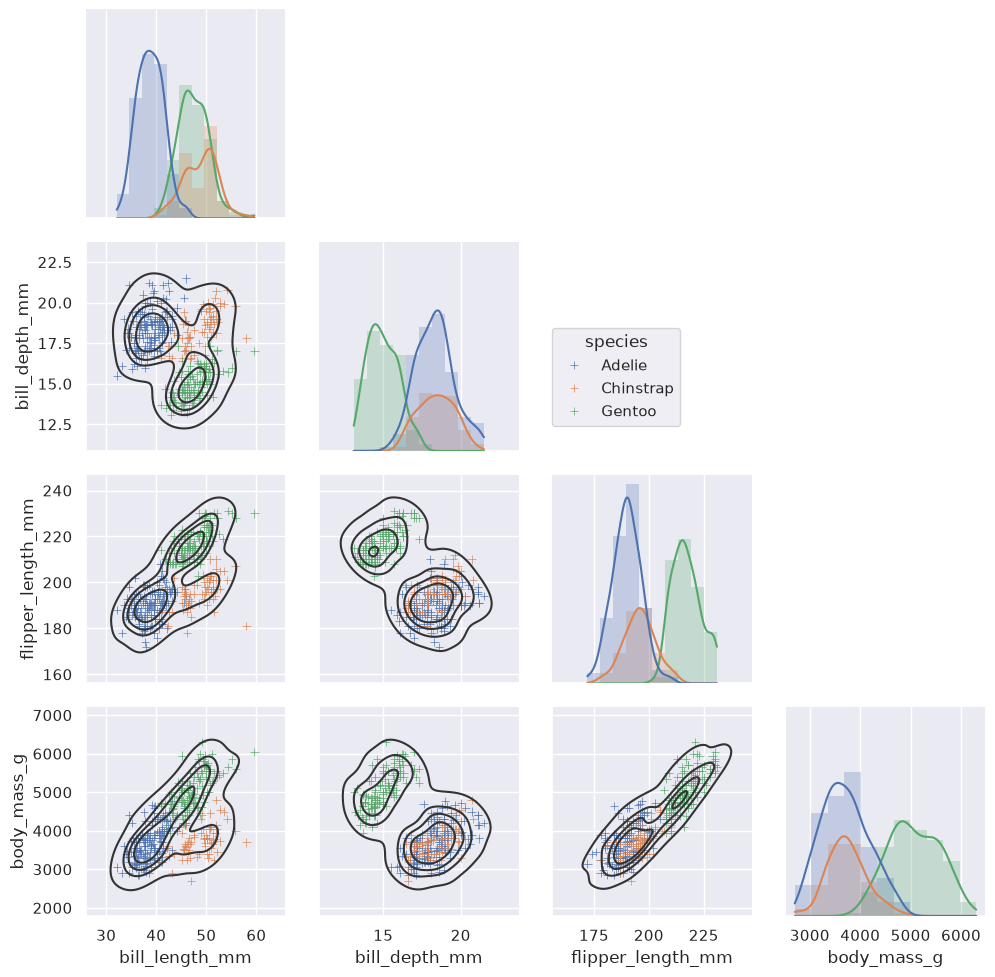

In [15]:
g = sns.PairGrid(penguins, hue="species", corner=True)          # grid of pairwise Axes, lower triangle only
g.map_lower(sns.kdeplot, hue=None, levels=5, color=".2")        # density contours (all species together)
g.map_lower(sns.scatterplot, marker="+")                        # points on top, coloured by species
g.map_diag(sns.histplot, element="step", linewidth=0, kde=True) # histograms on the diagonal
g.add_legend(frameon=True)
g.legend.set_bbox_to_anchor((.61, .6))                          # move the legend into the empty corner

## Opinionated defaults and flexible customization

Seaborn adds axis labels and legends automatically, and chooses defaults from the data. Categorical `hue` → distinct colours; **numeric** `hue` → a continuous gradient:

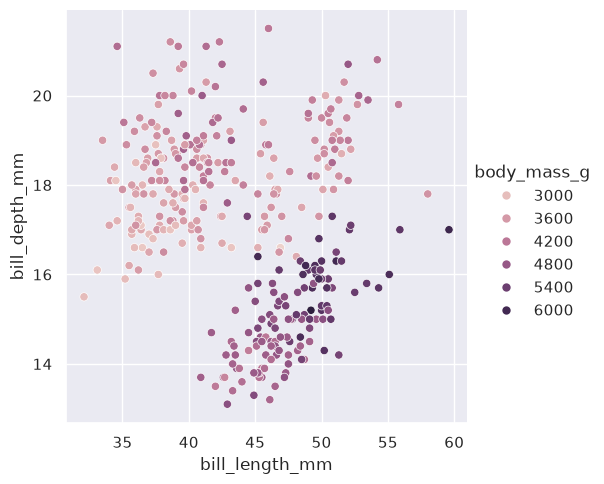

In [16]:
sns.relplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="body_mass_g"   # numeric hue -> colour gradient
)

To polish a figure: built-in themes, standard parameters for the mappings, extra keyword arguments passed down to matplotlib, and then **dropping down to the matplotlib layer** through the returned object:

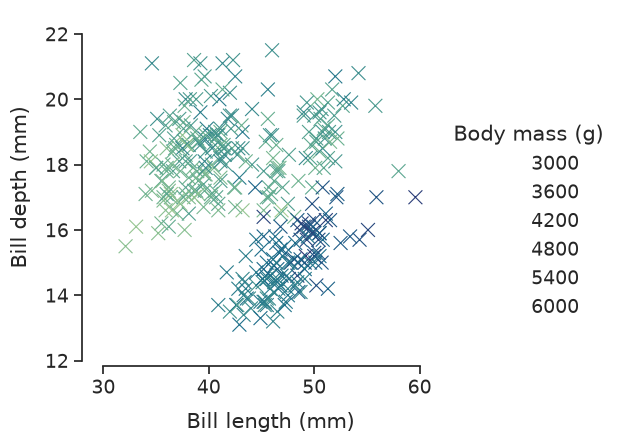

In [17]:
sns.set_theme(style="ticks", font_scale=1.25)        # theme for all following plots
g = sns.relplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="body_mass_g",
    palette="crest", marker="x", s=100,              # marker and s are passed to matplotlib's scatter
)
g.set_axis_labels("Bill length (mm)", "Bill depth (mm)", labelpad=10)   # seaborn grid method
g.legend.set_title("Body mass (g)")                                     # matplotlib Legend method
g.figure.set_size_inches(6.5, 4.5)                                      # matplotlib Figure method
g.ax.margins(.15)                                                       # matplotlib Axes method
g.despine(trim=True)                                                    # seaborn: trim the spines

### Relationship to matplotlib

Seaborn runs wherever matplotlib runs (notebooks, GUIs, saved files). You can do a lot with seaborn alone, but **full customization needs matplotlib**: knowing when to drop down to `g.figure` / `g.ax` is the main learning curve. Matplotlib knowledge transfers directly.

### Next steps
Example gallery, API reference, and the rest of this tutorial (notebooks 02-12).

## Key takeaways

- Pass a DataFrame to `data=` and map **column names** to roles: `x`, `y`, `hue`, `style`, `size`, `col`, `row`.
- Three figure-level entry points: `relplot` (relationships), `displot` (distributions), `catplot` (categories); switch views with `kind=`.
- Seaborn estimates for you: means with bootstrapped CIs, regressions, KDEs.
- The returned object gives access to matplotlib (`g.figure`, `g.ax`, `g.legend`) for final polish.